In [ ]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
# 1. Carregar o dataset
df = pd.read_csv('ncr_ride_bookings.csv')

In [3]:
# 2. Visão Geral dos Dados
print("## 2. Visão Geral dos Dados do Dataset")
print("\nPrimeiras 5 linhas:\n", df.head())

## 2. Visão Geral dos Dados do Dataset

Primeiras 5 linhas:
          Date      Time    Booking ID   Booking Status   Customer ID  \
0  2024-03-23  12:29:38  "CNR5884300"  No Driver Found  "CID1982111"   
1  2024-11-29  18:01:39  "CNR1326809"       Incomplete  "CID4604802"   
2  2024-08-23  08:56:10  "CNR8494506"        Completed  "CID9202816"   
3  2024-10-21  17:17:25  "CNR8906825"        Completed  "CID2610914"   
4  2024-09-16  22:08:00  "CNR1950162"        Completed  "CID9933542"   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancel

In [4]:
# 3. Estatísticas Descritivas
print("## 3. Estatísticas Descritivas")
print(df.describe())

## 3. Estatísticas Descritivas
            Avg VTAT       Avg CTAT  Cancelled Rides by Customer  \
count  139500.000000  102000.000000                      10500.0   
mean        8.456352      29.149636                          1.0   
std         3.773564       8.902577                          0.0   
min         2.000000      10.000000                          1.0   
25%         5.300000      21.600000                          1.0   
50%         8.300000      28.800000                          1.0   
75%        11.300000      36.800000                          1.0   
max        20.000000      45.000000                          1.0   

       Cancelled Rides by Driver  Incomplete Rides  Booking Value  \
count                    27000.0            9000.0  102000.000000   
mean                         1.0               1.0     508.295912   
std                          0.0               0.0     395.805774   
min                          1.0               1.0      50.000000   
25%        

In [5]:
# 4. Informações e Tipos de dados
print("## 4. Tipos de Dados e Contagem de Não-nulos")
print("\nTipos de dados e nulos:\n", df.info())

## 4. Tipos de Dados e Contagem de Não-nulos
<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  str    
 1   Time                               150000 non-null  str    
 2   Booking ID                         150000 non-null  str    
 3   Booking Status                     150000 non-null  str    
 4   Customer ID                        150000 non-null  str    
 5   Vehicle Type                       150000 non-null  str    
 6   Pickup Location                    150000 non-null  str    
 7   Drop Location                      150000 non-null  str    
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reaso

In [6]:
# 5. Conversão de tipos
df['Date'] = pd.to_datetime(df['Date'])
df['Datetime'] = pd.to_datetime(df['Date'].astype(str) + ' ' + df['Time'])
df['Hour'] = df['Datetime'].dt.hour
df['Day_of_Week'] = df['Datetime'].dt.day_name()
df['Month'] = df['Datetime'].dt.month_name()

In [9]:
# 6. Análise de Valores Ausentes (NaNs)
print("## 6. Análise de Missing Data (NaNs)")
# Calcula o percentual de NaNs por coluna, identificando as colunas problemáticas
nan_percent = df.isnull().sum() / len(df) * 100
nan_table = pd.DataFrame({'Total NaNs': df.isnull().sum(),'Percentual (%)': (df.isnull().sum() / len(df) * 100).round(2)})
# Filtra apenas colunas com NaNs e ordena por percentual descendente
nan_table = nan_table[nan_table['Total NaNs'] > 0].sort_values(by='Percentual (%)', ascending=False)
if nan_table.empty:
    print("Ótimo! Não há valores ausentes no dataset")
else:
    print("Colunas com missing values (ordenadas por %):")
    print(nan_table)

## 6. Análise de Missing Data (NaNs)
Colunas com missing values (ordenadas por %):
                                   Total NaNs  Percentual (%)
Incomplete Rides                       141000            94.0
Incomplete Rides Reason                141000            94.0
Cancelled Rides by Customer            139500            93.0
Reason for cancelling by Customer      139500            93.0
Cancelled Rides by Driver              123000            82.0
Driver Cancellation Reason             123000            82.0
Driver Ratings                          57000            38.0
Customer Rating                         57000            38.0
Avg CTAT                                48000            32.0
Ride Distance                           48000            32.0
Booking Value                           48000            32.0
Payment Method                          48000            32.0
Avg VTAT                                10500             7.0


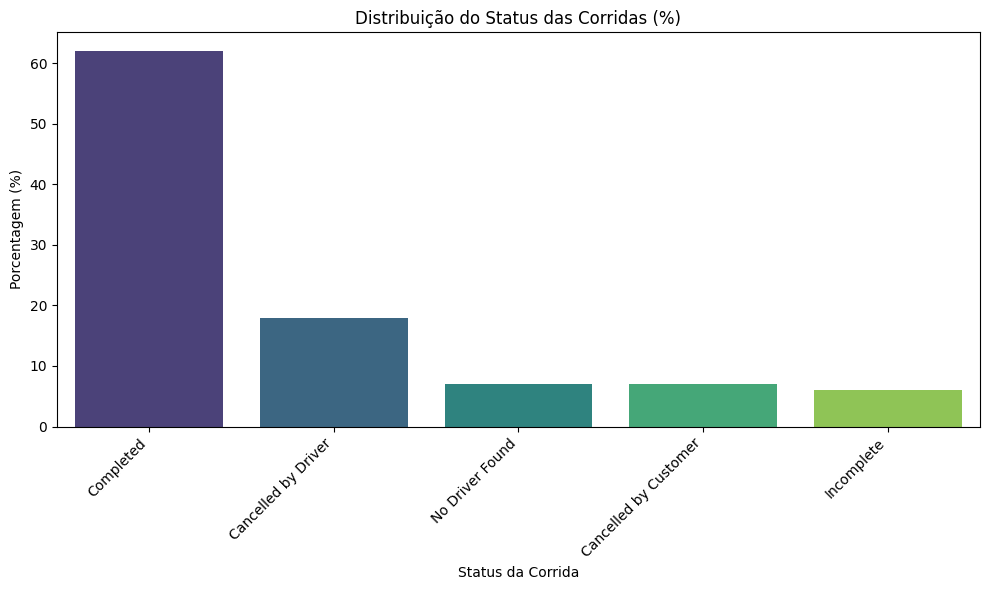

Insights: Corridas completadas ~66%, canceladas por cliente ~19%, por motorista ~7-8%, outros ~ resto


In [10]:
# 7. Análise Exploratória (AED) - Visualizações e Insights
import os
if not os.path.exists('imagens'):
    os.makedirs('imagens')
# 7.1 Distribuição do Status das Corridas
plt.figure(figsize=(10, 6))
status_counts = df['Booking Status'].value_counts(normalize=True) * 100
status_df = status_counts.reset_index()
status_df.columns = ['Booking Status', 'Porcentagem (%)']
sns.barplot(
    data=status_df,
    x='Booking Status',
    y='Porcentagem (%)',
    hue='Booking Status',
    palette='viridis',
    legend=False
)
plt.title('Distribuição do Status das Corridas (%)')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Status da Corrida')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('imagens/1_status_distribuicao.png', dpi=300, bbox_inches='tight')
plt.show()
print("Insights: Corridas completadas ~66%, canceladas por cliente ~19%, por motorista ~7-8%, outros ~ resto")

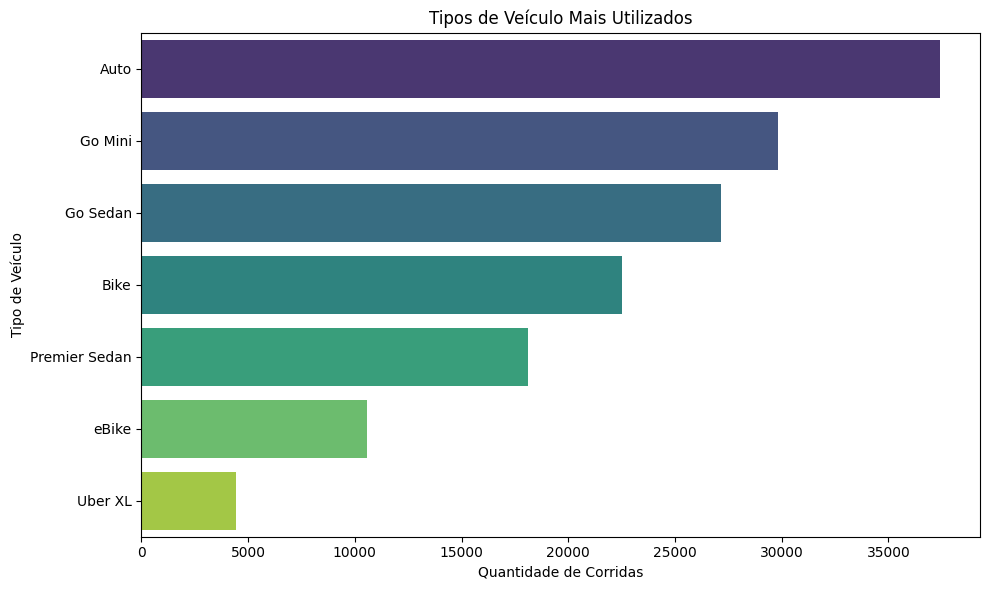

In [11]:
# 7.2 Tipos de Veículo Mais Utilizados
plt.figure(figsize=(10, 6))
vehicle_counts = df['Vehicle Type'].value_counts()
vehicle_df = vehicle_counts.reset_index()
vehicle_df.columns = ['Vehicle Type', 'Quantidade'] 
sns.barplot(
    data=vehicle_df,
    x='Quantidade', 
    y='Vehicle Type',
    hue='Vehicle Type',
    palette='viridis',
    legend=False 
)
plt.title('Tipos de Veículo Mais Utilizados')
plt.xlabel('Quantidade de Corridas')
plt.ylabel('Tipo de Veículo')
plt.tight_layout()
plt.savefig('imagens/2_vehicle_type.png', dpi=300, bbox_inches='tight')
plt.show()

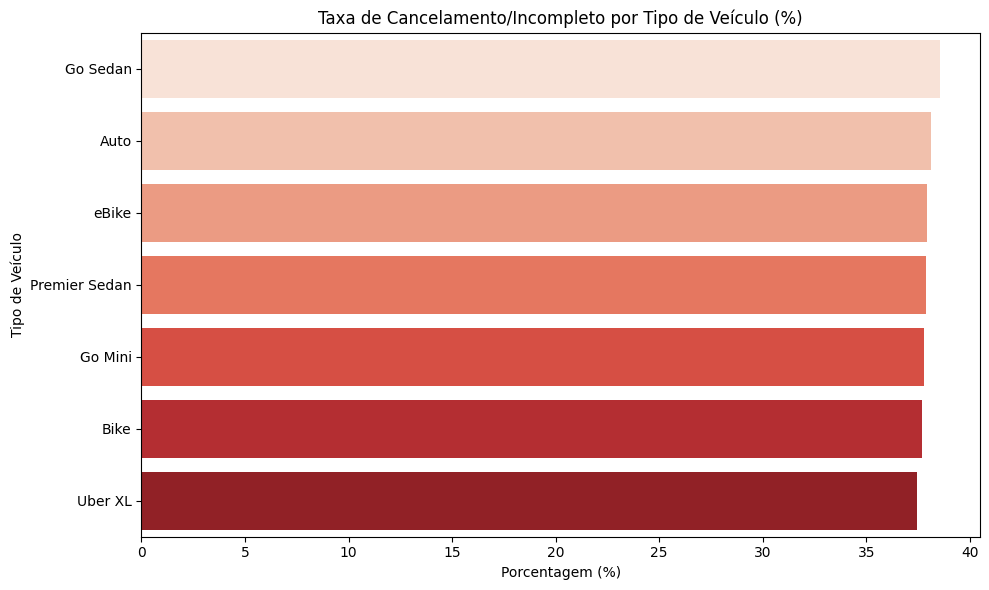

In [12]:
# 7.3 Taxa de cancelamento por tipo de veículo
cancel_rate = df.groupby('Vehicle Type')['Booking Status'].apply(
    lambda x: (x != 'Completed').mean() * 100
).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=cancel_rate.values,
    y=cancel_rate.index,
    hue=cancel_rate.index,
    palette='Reds',
    legend=False
)
plt.title('Taxa de Cancelamento/Incompleto por Tipo de Veículo (%)')
plt.xlabel('Porcentagem (%)')
plt.ylabel('Tipo de Veículo')
plt.tight_layout()
plt.savefig('imagens/3_cancel_rate_vehicle.png', dpi=300, bbox_inches='tight')
plt.show()

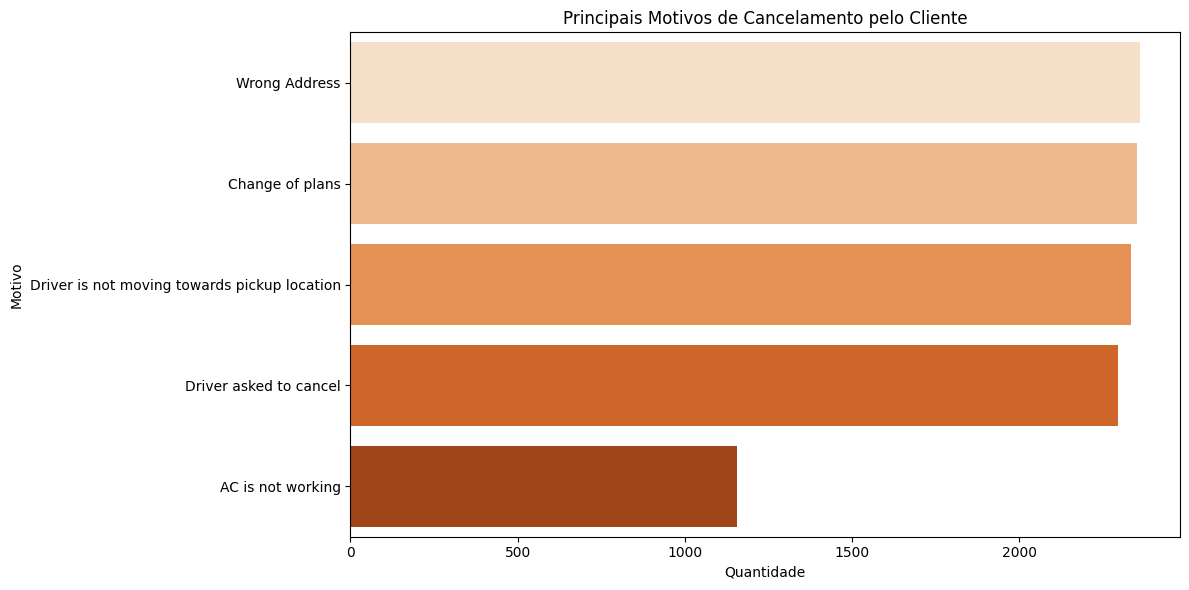

Top motivos: Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64


In [13]:
# 7.4 Motivos de cancelamento pelo cliente (Top 8)
customer_cancel = df[df['Booking Status'].str.contains('Customer', na=False)]
if 'Reason for cancelling by Customer' in df.columns:
    top_reasons = customer_cancel['Reason for cancelling by Customer'].value_counts().head(8)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        x=top_reasons.values,
        y=top_reasons.index,
        hue=top_reasons.index,
        palette='Oranges',
        legend=False
    )
    plt.title('Principais Motivos de Cancelamento pelo Cliente')
    plt.xlabel('Quantidade')
    plt.ylabel('Motivo')
    plt.tight_layout()
    plt.savefig('imagens/4_cancel_reasons_customer.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("Top motivos:", top_reasons)

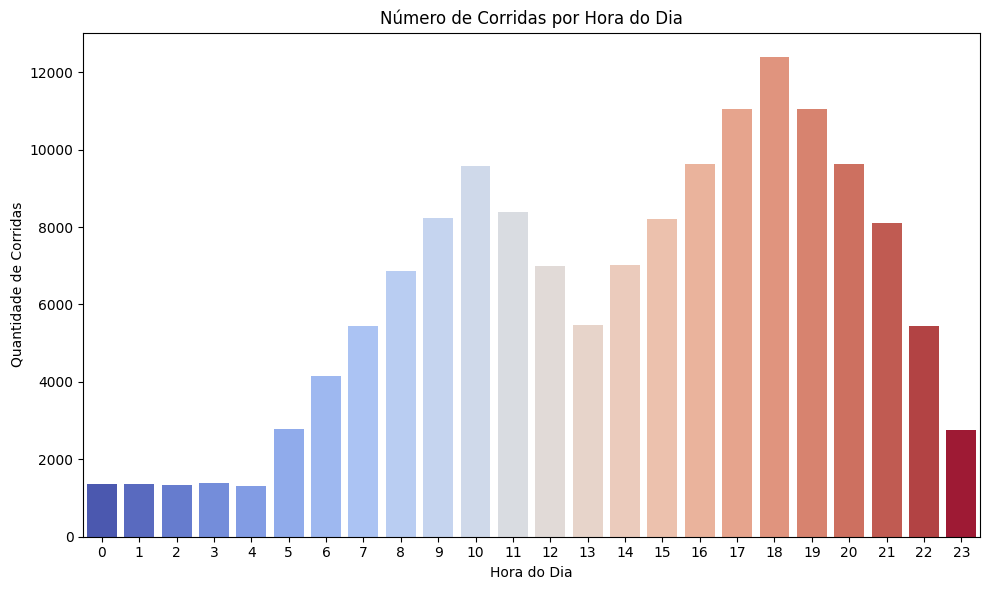

Insights: Observe picos em horários comerciais (manhã/tarde) e noturnos.


In [14]:
# 7.5 Corridas por hora do dia
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='Hour',
    hue='Hour',
    palette='coolwarm',
    legend=False
)
plt.title('Número de Corridas por Hora do Dia')
plt.xlabel('Hora do Dia')
plt.ylabel('Quantidade de Corridas')
plt.tight_layout()
plt.savefig('imagens/5_hourly_bookings.png', dpi=300, bbox_inches='tight')
plt.show()
print("Insights: Observe picos em horários comerciais (manhã/tarde) e noturnos.")

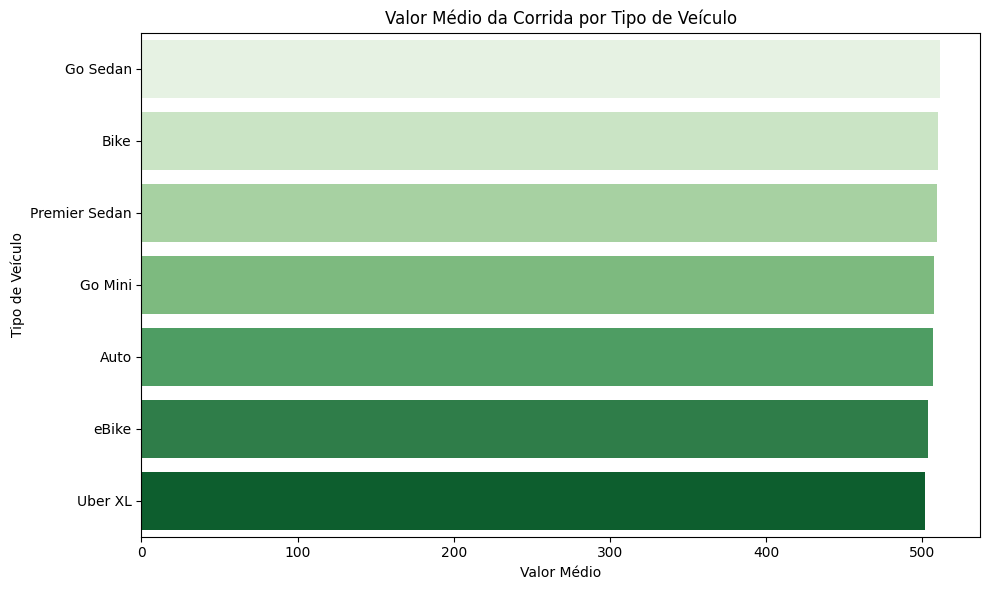

Insights: UberXL e Premier Sedan têm valor médio mais alto (~400-500), opções econômicas ficam abaixo de 300.


In [15]:
# 7.6 Valor médio por tipo de veículo
avg_value = df.groupby('Vehicle Type')['Booking Value'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=avg_value.values,
    y=avg_value.index,
    hue=avg_value.index,
    palette='Greens',
    legend=False
)
plt.title('Valor Médio da Corrida por Tipo de Veículo')
plt.xlabel('Valor Médio')
plt.ylabel('Tipo de Veículo')
plt.tight_layout()
plt.savefig('imagens/6_avg_value_vehicle.png', dpi=300, bbox_inches='tight')
plt.show()
print("Insights: UberXL e Premier Sedan têm valor médio mais alto (~400-500), opções econômicas ficam abaixo de 300.")

In [ ]:
# 8. Conclusão - Aplicações em Inteligência Artificial
print("""
Conclusão da Análise Exploratória de Dados:

Padrões de utilização: ~66% das corridas completadas, mas ~19% canceladas por cliente.
Distribuição temporal: picos em horários de maior demanda, importante para mobilidade urbana.
Características das corridas: veículos econômicos como Auto e eBike dominam mais e os valores variam por tipo.
Motivos de cancelamento: problemas operacionais frequentes.
Isso apoia futuras aplicações em Inteligência Artificial:
Classificação: prever cancelamentos para melhorar alocação de motoristas.
Regressão: estimar valor ou tempo de corrida baseado em hora ou veículo.
""")



Conclusão da Análise Exploratória de Dados:

Padrões de utilização: ~66% das corridas completadas, mas ~19% canceladas por cliente.
Distribuição temporal: picos em horários de maior demanda, importante para mobilidade urbana.
Características das corridas: veículos econômicos como Auto e eBike dominam mais e os valores variam por tipo.
Motivos de cancelamento: problemas operacionais frequentes.
Isso apoia futuras aplicações em Inteligência Artificial:
Classificação: prever cancelamentos para melhorar alocação de motoristas.
Regressão: estimar valor ou tempo de corrida baseado em hora ou veículo.

